<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Question6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 6

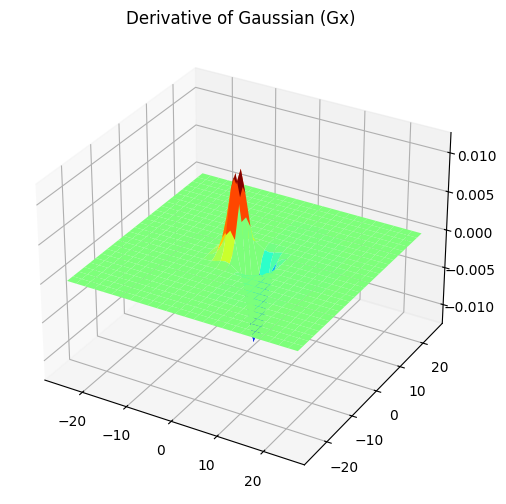

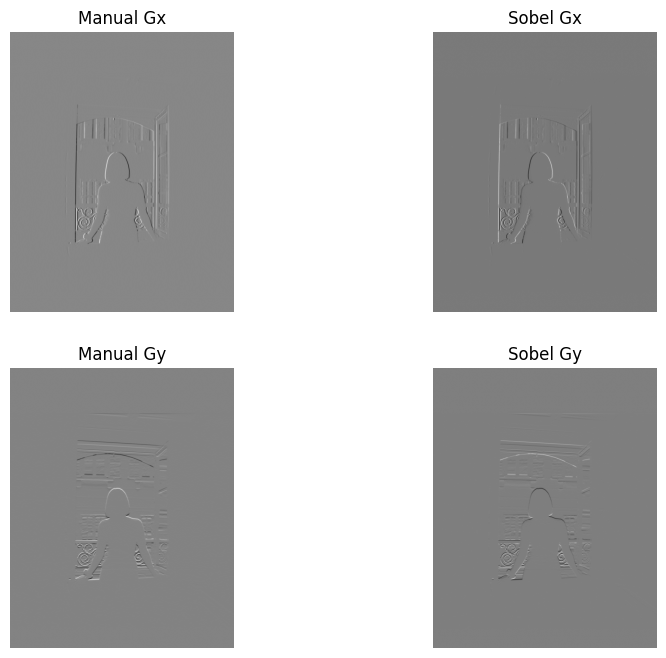

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dog_kernel(sigma, size):
    # Make a grid centered at 0
    k = size // 2
    x, y = np.meshgrid(np.arange(-k, k + 1), np.arange(-k, k + 1))

    # Standard Gaussian formula
    g = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

    # Derivative formulas: Gx = -x/sigma^2 * G, Gy = -y/sigma^2 * G
    gx = -(x / sigma**2) * g
    gy = -(y / sigma**2) * g

    return gx, gy

# 1. Get kernels
sigma = 2
gx_k, gy_k = dog_kernel(sigma, 5)

# 2. Visualize 3D plot (using a larger size for better view)
gx_large, _ = dog_kernel(sigma, 51)
x_grid, y_grid = np.meshgrid(np.arange(-25, 26), np.arange(-25, 26))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_grid, y_grid, gx_large, cmap='jet')
plt.title('Derivative of Gaussian (Gx)')
plt.show()

# 3. Apply to image and compare with Sobel
img = cv2.imread('/content/drive/MyDrive/Assignment1/looking_out.jpg', 0)

# Manual filter
manual_x = cv2.filter2D(img, cv2.CV_64F, gx_k)
manual_y = cv2.filter2D(img, cv2.CV_64F, gy_k)

# OpenCV Sobel
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

# Plot comparison
plt.figure(figsize=(10, 8))
titles = ['Manual Gx', 'Sobel Gx', 'Manual Gy', 'Sobel Gy']
images = [manual_x, sobel_x, manual_y, sobel_y]

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()